In [1]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import folium

In [2]:
import requests
import io
import pandas as pd

# URL of the CSV file
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/d51iMGfp_t0QpO30Lym-dw/automobile-sales.csv"

# Fetch the data from the URL
response = requests.get(URL)

# Raise an error if the request failed
response.raise_for_status()

# Convert the response content into a readable format for pandas
csv_content = io.StringIO(response.text)

# Read the CSV data into a pandas dataframe
df = pd.read_csv(csv_content)

# Print confirmation
print('Data downloaded and read into a dataframe!')

# Optional: Show the first few rows of the dataframe
print(df.head())

Data downloaded and read into a dataframe!
         Date  Year Month  Recession  Consumer_Confidence  Seasonality_Weight  \
0  1980-01-31  1980   Jan          1               108.24                0.45   
1  1980-01-31  1980   Jan          1               108.24                0.45   
2  1980-01-31  1980   Jan          1               108.24                0.36   
3  1980-01-31  1980   Jan          1               108.24                0.38   
4  1980-02-29  1980   Feb          1                98.75                0.46   

   Price  Advertising_Expenditure  Competition    GDP  Growth_Rate  \
0  27704                   1417.5            7  60.22         0.01   
1  77270                    763.7            7  60.22         0.01   
2  19665                   1417.5            7  60.22         0.01   
3  36986                   1417.5            7  60.22         0.01   
4  26609                   2773.4            4  45.99        -0.31   

   unemployment_rate  Automobile_Sales     Vehicl

In [3]:
df.describe()

,Year,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales
count,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000
mean,2001.520833,0.224432,101.210890,0.737756,41469.506155,2879.743655,6.118845,40.205748,-0.237074,2.441525,3164.160511
std,12.535031,0.417306,10.634092,0.286092,21388.409141,1175.338324,1.964292,16.291271,0.859691,1.108472,3640.137399
min,1980.000000,0.000000,73.900000,0.250000,15001.000000,494.200000,3.000000,12.510000,-4.230000,1.000000,40.000000
25%,1991.000000,0.000000,94.060000,0.500000,22039.000000,1872.000000,4.000000,27.210000,-0.570000,1.600000,923.000000
50%,2002.000000,0.000000,100.800000,0.810000,34957.500000,2883.500000,6.000000,39.420000,-0.005000,2.300000,2381.500000
75%,2012.000000,0.000000,108.320000,0.940000,57418.250000,3902.425000,8.000000,53.862500,0.392500,2.900000,4363.500000
max,2023.000000,1.000000,131.670000,1.500000,79998.000000,4983.000000,9.000000,70.370000,0.820000,6.000000,65645.000000


In [4]:
df.columns

Index(['Date', 'Year', 'Month', 'Recession', 'Consumer_Confidence',
       'Seasonality_Weight', 'Price', 'Advertising_Expenditure', 'Competition',
       'GDP', 'Growth_Rate', 'unemployment_rate', 'Automobile_Sales',
       'Vehicle_Type', 'City'],
      dtype='object')

In [5]:
df.head()

,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1980-01-31,1980,Jan,1,108.24,0.45,27704,1417.5,7,60.22,0.01,5.4,220.0,SmallFamilyCar,Georgia
1,1980-01-31,1980,Jan,1,108.24,0.45,77270,763.7,7,60.22,0.01,5.4,72.0,Sports,Georgia
2,1980-01-31,1980,Jan,1,108.24,0.36,19665,1417.5,7,60.22,0.01,5.4,238.0,SuperMiniCar,Georgia
3,1980-01-31,1980,Jan,1,108.24,0.38,36986,1417.5,7,60.22,0.01,5.4,224.0,MediumFamilyCar,Georgia
4,1980-02-29,1980,Feb,1,98.75,0.46,26609,2773.4,4,45.99,-0.31,4.8,280.0,SmallFamilyCar,New York


Tren penjualan tahunan, tandai tahun resesi (line chart)

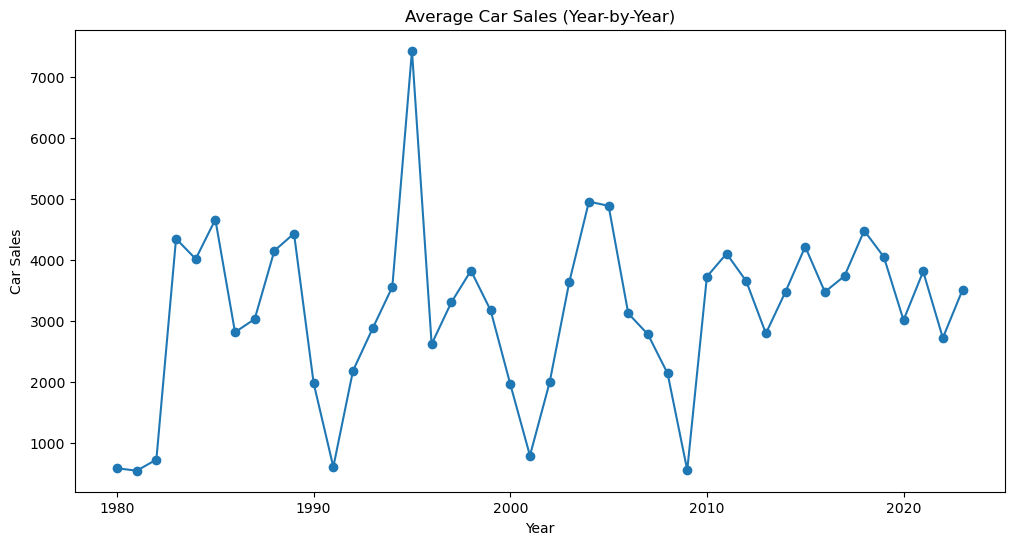

In [6]:
df_line = df.groupby('Year')['Automobile_Sales'].mean()
plt.figure(figsize=(12, 6))
df_line.plot(kind='line', marker='o')
plt.xlabel('Year')
plt.ylabel('Car Sales')
plt.title('Average Car Sales (Year-by-Year)')
plt.show()

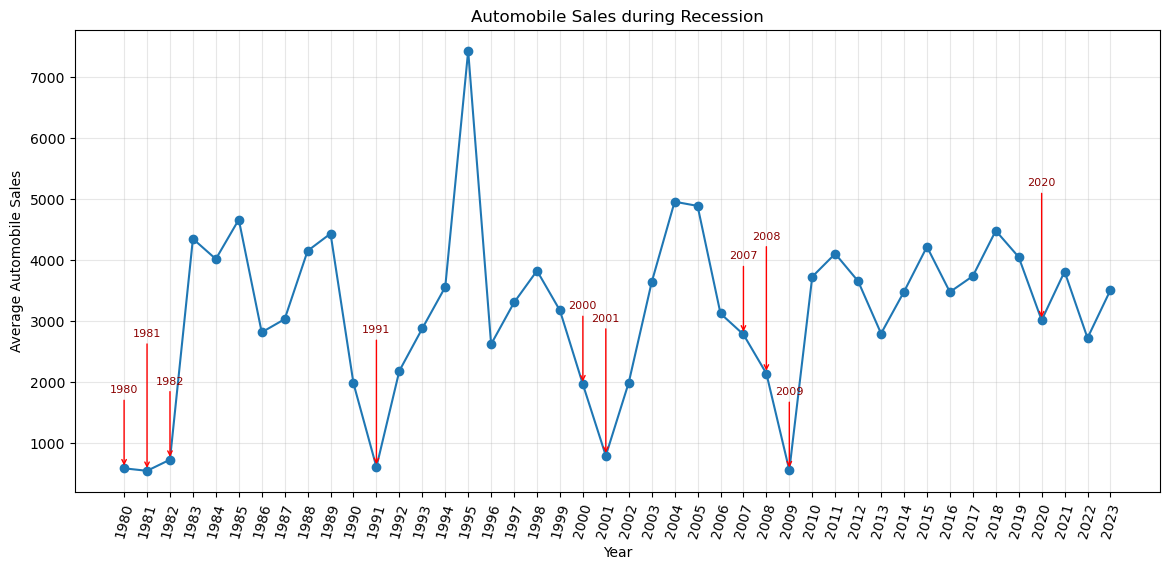

In [7]:
df_line = df.groupby('Year')['Automobile_Sales'].mean()
recession_years = sorted(df[df['Recession'] == 1]['Year'].unique())

plt.figure(figsize=(14, 6))
df_line.plot(kind='line', marker='o')

# panah untuk SEMUA tahun resesi, teks di-stagger biar nggak numpuk
rng = df_line.max() - df_line.min()
for i, yr in enumerate(recession_years):
    y_val = df_line.loc[yr]
    # selang-seling tinggi teks: ganjil lebih tinggi, genap lebih rendah
    text_offset = rng * (0.18 if i % 2 == 0 else 0.32)
    plt.annotate(f'{yr}',
                 xy=(yr, y_val),
                 xytext=(yr, y_val + text_offset),
                 ha='center', fontsize=8, color='darkred',
                 arrowprops=dict(arrowstyle='->', color='red', lw=1))

plt.xlabel('Year')
plt.ylabel('Average Automobile Sales')
plt.title('Automobile Sales during Recession')
plt.xticks(df_line.index, rotation=75)
plt.grid(True, alpha=0.3)
plt.show()

Iklan vs penjualan saat non-resesi (regplot)

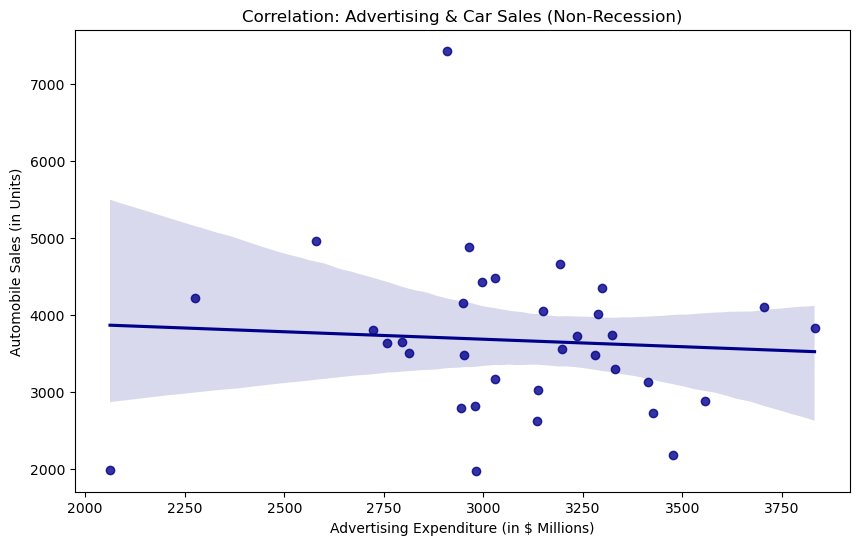

-0.069018447769575


In [8]:
non_rec = df[df['Recession'] == 0]
non_rec = non_rec.groupby('Year').mean(numeric_only=True)

plt.figure(figsize=(10, 6))
sns.regplot(x=non_rec['Advertising_Expenditure'],
            y=non_rec['Automobile_Sales'],
            color='darkblue')
plt.title('Correlation: Advertising & Car Sales (Non-Recession)')
plt.xlabel('Advertising Expenditure (in $ Millions)')
plt.ylabel('Automobile Sales (in Units)')
plt.show()
print(non_rec['Advertising_Expenditure'].corr(non_rec['Automobile_Sales']))

Penjualan per jenis kendaraan: resesi vs non-resesi (bar)

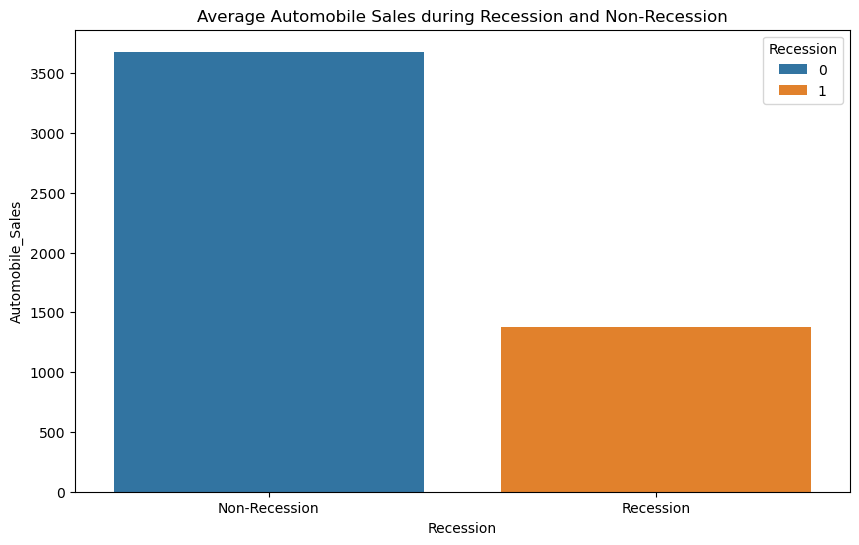

In [9]:
new_df = df.groupby('Recession')['Automobile_Sales'].mean().reset_index()

# Create the bar chart using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Recession', y='Automobile_Sales', hue='Recession',  data=new_df)
plt.xlabel('Recession')
plt.ylabel('Automobile_Sales')
plt.title('Average Automobile Sales during Recession and Non-Recession')
plt.xticks(ticks=[0, 1], labels=['Non-Recession', 'Recession'])
plt.show()

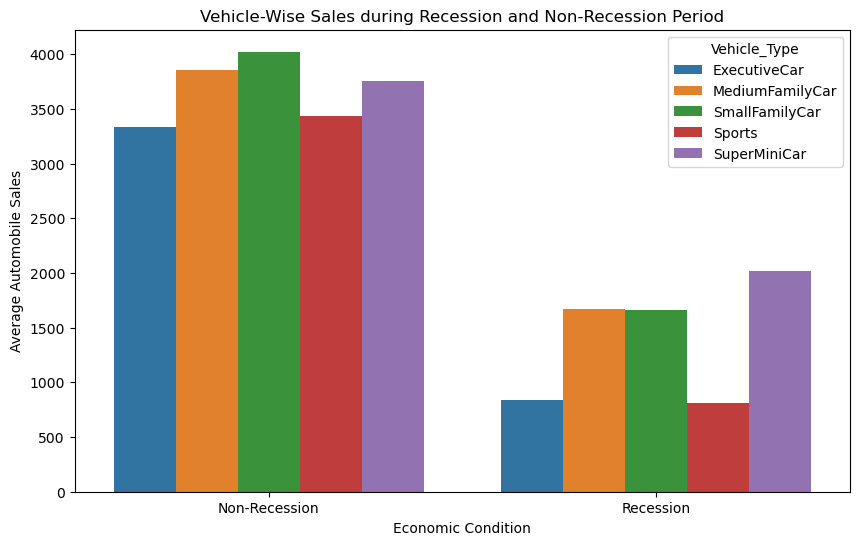

In [10]:
import seaborn as sns

grouped_df = df.groupby(['Recession', 'Vehicle_Type'])['Automobile_Sales'].mean().reset_index()
# Create the grouped bar chart using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Recession', y='Automobile_Sales', hue='Vehicle_Type', data=grouped_df)
plt.xticks(ticks=[0, 1], labels=['Non-Recession', 'Recession'])
plt.xlabel('Economic Condition')
plt.ylabel('Average Automobile Sales')
plt.title('Vehicle-Wise Sales during Recession and Non-Recession Period')

plt.show()

Variasi GDP antar periode (subplot line)

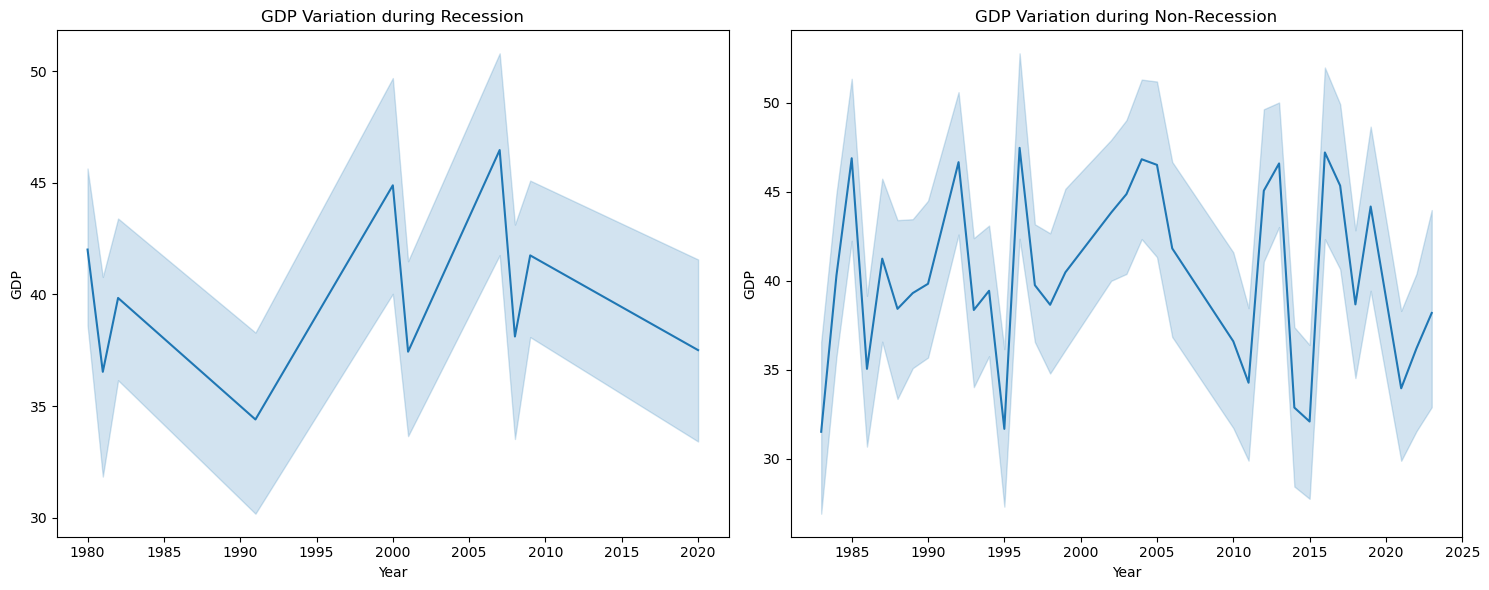

In [11]:
rec = df[df['Recession'] == 1]
non_rec = df[df['Recession'] == 0]

fig = plt.figure(figsize=(15, 6))

# kiri: GDP selama resesi
ax0 = fig.add_subplot(1, 2, 1)
sns.lineplot(data=rec, x='Year', y='GDP', ax=ax0)
ax0.set_title('GDP Variation during Recession')
ax0.set_xlabel('Year')
ax0.set_ylabel('GDP')

# kanan: GDP selama non-resesi
ax1 = fig.add_subplot(1, 2, 2)
sns.lineplot(data=non_rec, x='Year', y='GDP', ax=ax1)
ax1.set_title('GDP Variation during Non-Recession')
ax1.set_xlabel('Year')
ax1.set_ylabel('GDP')

plt.tight_layout()
plt.show()

Pengaruh musim terhadap penjualan (bubble plot)

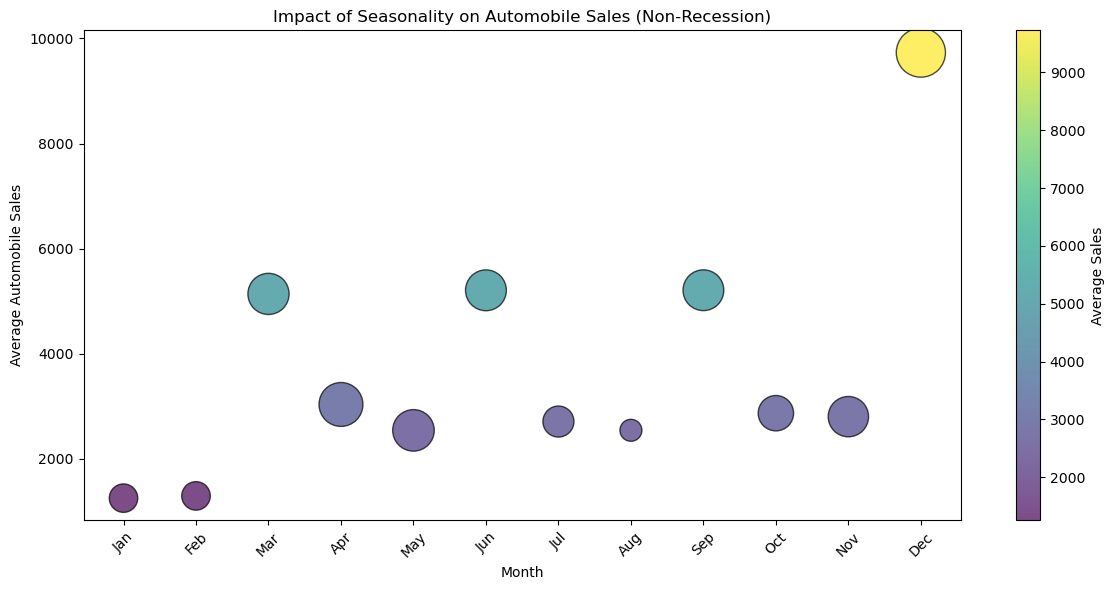

In [12]:
non_rec = df[df['Recession'] == 0]

monthly = non_rec.groupby('Month').agg(
    sales=('Automobile_Sales', 'mean'),
    weight=('Seasonality_Weight', 'mean')
).reset_index()

# urutkan bulan secara kronologis, bukan alfabetis
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly['Month'] = pd.Categorical(monthly['Month'], categories=month_order, ordered=True)
monthly = monthly.sort_values('Month')

plt.figure(figsize=(12, 6))
scatter = plt.scatter(monthly['Month'], monthly['sales'],
                      s=monthly['weight'] * 1000,
                      c=monthly['sales'],        # warna ikut nilai penjualan
                      cmap='viridis',
                      alpha=0.7, edgecolors='black')

plt.colorbar(scatter, label='Average Sales')   # legenda warna
plt.xlabel('Month')
plt.ylabel('Average Automobile Sales')
plt.title('Impact of Seasonality on Automobile Sales (Non-Recession)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Consumer confidence vs penjualan saat resesi (scatter)

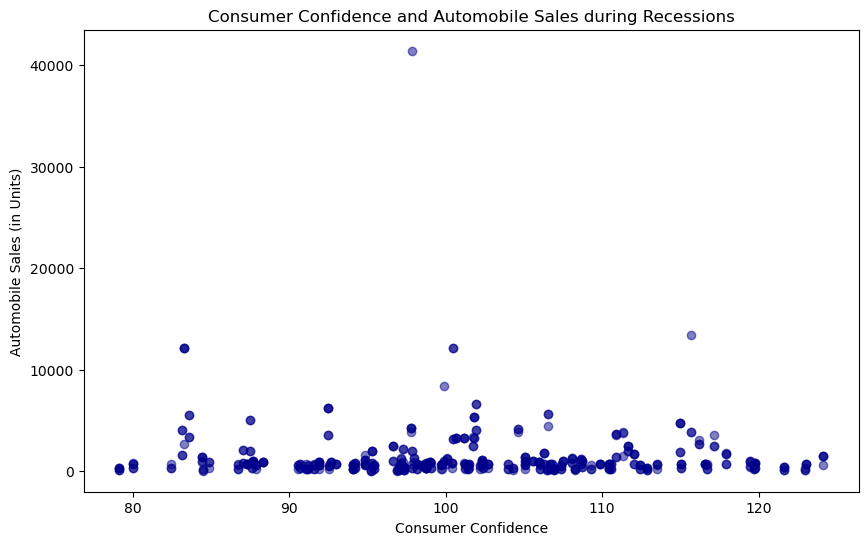

-0.05032029619276068


In [13]:
rec = df[df['Recession'] == 1]

plt.figure(figsize=(10, 6))
plt.scatter(rec['Consumer_Confidence'], rec['Automobile_Sales'],
            color='darkblue', alpha=0.5)
plt.title('Consumer Confidence and Automobile Sales during Recessions')
plt.xlabel('Consumer Confidence')
plt.ylabel('Automobile Sales (in Units)')
plt.show()

print(rec['Consumer_Confidence'].corr(rec['Automobile_Sales']))

Porsi belanja iklan: resesi vs non-resesi (pie)

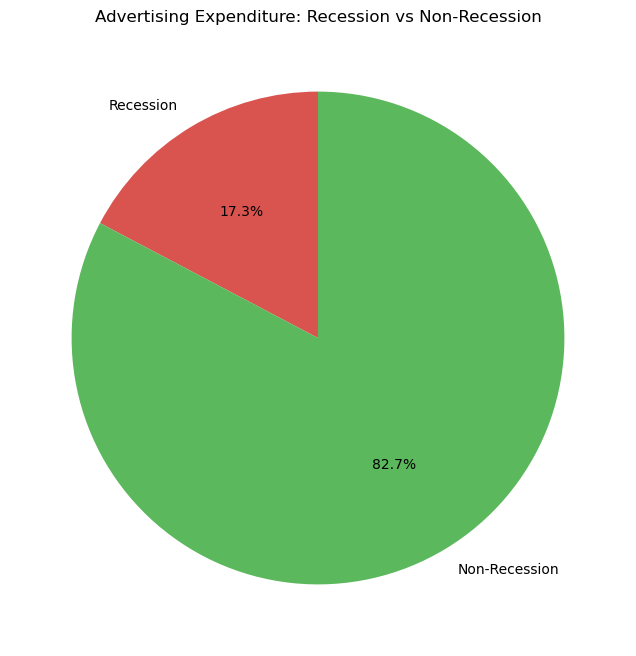

In [14]:
# total belanja iklan di tiap periode
rec_total = df[df['Recession'] == 1]['Advertising_Expenditure'].sum()
non_rec_total = df[df['Recession'] == 0]['Advertising_Expenditure'].sum()

plt.figure(figsize=(8, 8))
plt.pie([rec_total, non_rec_total],
        labels=['Recession', 'Non-Recession'],
        autopct='%1.1f%%',
        colors=['#d9534f', '#5cb85c'],
        startangle=90)
plt.title('Advertising Expenditure: Recession vs Non-Recession')
plt.show()

Belanja iklan per jenis kendaraan saat resesi (pie)

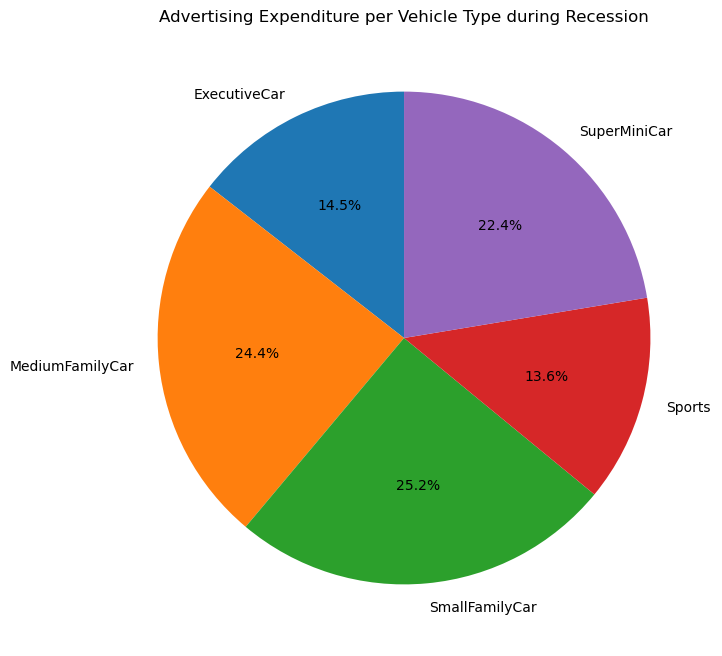

In [15]:
rec = df[df['Recession'] == 1]
ad_by_type = rec.groupby('Vehicle_Type')['Advertising_Expenditure'].sum()

plt.figure(figsize=(8, 8))
plt.pie(ad_by_type,
        labels=ad_by_type.index,
        autopct='%1.1f%%',
        startangle=90)
plt.title('Advertising Expenditure per Vehicle Type during Recession')
plt.show()

Efek pengangguran terhadap penjualan per jenis (line plot)

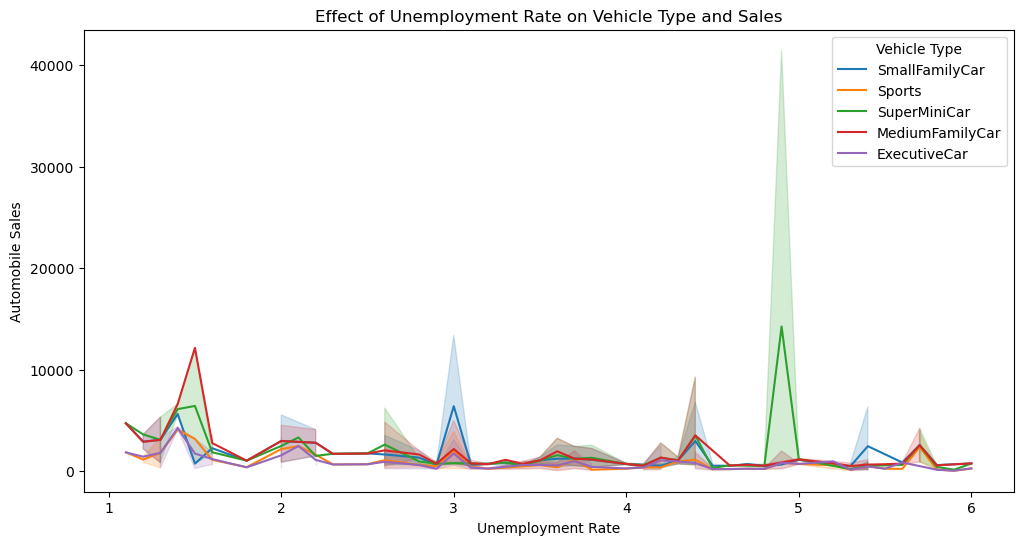

In [16]:
rec = df[df['Recession'] == 1]

plt.figure(figsize=(12, 6))
sns.lineplot(data=rec, x='unemployment_rate', y='Automobile_Sales',
             hue='Vehicle_Type')
plt.title('Effect of Unemployment Rate on Vehicle Type and Sales')
plt.xlabel('Unemployment Rate')
plt.ylabel('Automobile Sales')
plt.legend(title='Vehicle Type')
plt.show()

Penjualan tertinggi per wilayah (Folium choropleth)

In [17]:
import urllib.request

path = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/us-states.json'
urllib.request.urlretrieve(path, 'us-states.json')
filename = "us-states.json"
print('Downloaded')

Downloaded


In [18]:
recession_data = df[df['Recession'] == 1]
sales_by_city = recession_data.groupby('City')['Automobile_Sales'].sum().reset_index()

map1 = folium.Map(location=[37.0902, -95.7129], zoom_start=4)

choropleth = folium.Choropleth(
    geo_data='us-states.json',
    data=sales_by_city,
    columns=['City', 'Automobile_Sales'],
    key_on='feature.properties.name',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    nan_fill_color='white',        # ← state tanpa data jadi putih
    nan_fill_opacity=0.3,
    legend_name='Automobile Sales during Recession'
).add_to(map1)

choropleth.geojson.add_child(
    folium.features.GeoJsonTooltip(['name'], labels=True)
)

map1